In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/cleaned_loan_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 5)


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['income', 'credit_score', 'loan_amount', 'employment_years', 'loan_status']

First 5 rows:


,income,credit_score,loan_amount,employment_years,loan_status
0,141958,760,43525,16,1
1,35795,846,37556,4,1
2,20860,552,17595,11,1
3,123694,689,6969,10,1
4,148106,555,48753,14,0



Data types:
income              int64
credit_score        int64
loan_amount         int64
employment_years    int64
loan_status         int64
dtype: object

Missing values:
income              0
credit_score        0
loan_amount         0
employment_years    0
loan_status         0
dtype: int64


In [4]:
X = df.drop(columns=["loan_status"])
y = df["loan_status"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("loan_status")

print("\nX shape:", X.shape)
print("y shape:", y.shape)


print("Loan Status Distribution:")
print(y.value_counts())

print("\nLoan Status Percentage:")
print(y.value_counts(normalize=True) * 100)

Features:
['income', 'credit_score', 'loan_amount', 'employment_years']

Target:
loan_status

X shape: (1000, 4)
y shape: (1000,)
Loan Status Distribution:
loan_status
1    500
0    500
Name: count, dtype: int64

Loan Status Percentage:
loan_status
1    50.0
0    50.0
Name: proportion, dtype: float64


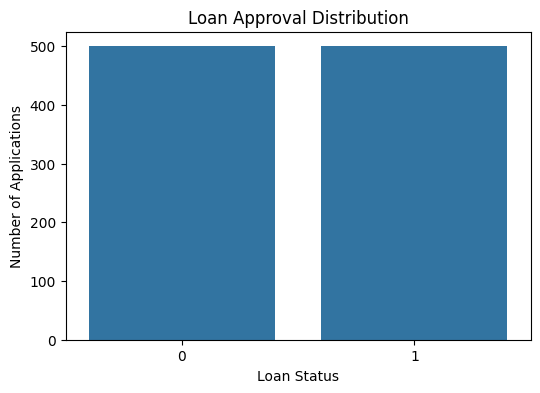

In [5]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (800, 4)
Testing data : (200, 4)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

scaler.transform(X_test)

Feature scaling completed!


array([[-1.52990287e-01,  4.10680734e-02, -1.31906198e+00,
         5.35042051e-02],
       [-8.71364419e-01,  8.46849012e-01,  9.42018019e-01,
        -9.90480284e-01],
       [-3.93324203e-01, -7.33237047e-01,  1.62870470e+00,
         1.27148611e+00],
       [-6.51069389e-01, -1.19278399e+00, -5.40464687e-01,
         1.09748869e+00],
       [ 1.25562391e+00,  3.18055271e-01, -1.01910992e+00,
         7.49493864e-01],
       [ 1.14035388e+00,  2.36218145e-01,  7.86598353e-01,
        -1.20493210e-01],
       [ 1.27308827e+00,  9.85342611e-01,  1.16938831e+00,
         1.27148611e+00],
       [ 1.20819413e+00,  7.52421558e-01, -8.75287560e-01,
        -8.16482869e-01],
       [-7.88422013e-01, -9.85043591e-01,  8.71329684e-01,
         5.75496450e-01],
       [ 1.52905517e+00, -1.46977119e+00, -4.68356274e-01,
        -1.51247253e+00],
       [ 1.47286666e+00,  6.13927960e-01,  7.37605657e-01,
         7.49493864e-01],
       [ 3.81716181e-01,  1.48266053e+00,  1.05933225e+00,
      

## 7. Logistic Regression Model

Logistic Regression is a supervised machine learning classification algorithm used
to predict the loan approval status.

In this project, Logistic Regression is trained using the standardized training
features. The model learns the relationship between the applicant's income,
credit score, loan amount, and employment years and the loan status.

### Why Logistic Regression?

Logistic Regression is used as a baseline classification model because it is:
- Simple and easy to interpret
- Suitable for binary classification
- Efficient for small and medium-sized datasets
- Useful for comparing the performance of more complex models

The model is trained using the scaled training data and evaluated using:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

print("Metrics imported successfully!")

Metrics imported successfully!


In [9]:
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [10]:
print("Logistic Regression Results")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_test, logistic_pred))
print("Precision:", precision_score(y_test, logistic_pred))
print("Recall   :", recall_score(y_test, logistic_pred))
print("F1 Score :", f1_score(y_test, logistic_pred))
print("ROC-AUC  :", roc_auc_score(y_test, logistic_prob))

Logistic Regression Results
--------------------------------
Accuracy : 0.995
Precision: 0.9900990099009901
Recall   : 1.0
F1 Score : 0.9950248756218906
ROC-AUC  : 0.9999


In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print("--------------------------------")
print("Accuracy :", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall   :", recall_score(y_test, dt_pred))
print("F1 Score :", f1_score(y_test, dt_pred))
print("ROC-AUC  :", roc_auc_score(y_test, dt_prob))

Decision Tree Results
--------------------------------
Accuracy : 0.96
Precision: 0.9693877551020408
Recall   : 0.95
F1 Score : 0.9595959595959596
ROC-AUC  : 0.9714


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Random Forest Results
--------------------------------
Accuracy : 0.965
Precision: 0.9696969696969697
Recall   : 0.96
F1 Score : 0.964824120603015
ROC-AUC  : 0.9972


In [13]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

            Feature  Importance
1      credit_score    0.670605
2       loan_amount    0.157932
3  employment_years    0.104940
0            income    0.066523


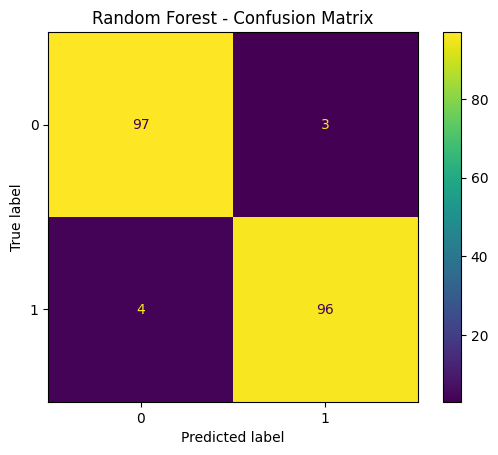

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [15]:
import joblib

joblib.dump(rf_model, "loan_approval_model.pkl")

['loan_approval_model.pkl']

In [16]:
import joblib
import pandas as pd

# Load the saved model
model = joblib.load("loan_approval_model.pkl")

# Test applicant
test_data = pd.DataFrame([{
    "income": 100000,
    "credit_score": 750,
    "loan_amount": 20000,
    "employment_years": 10
}])

# Make prediction
prediction = model.predict(test_data)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Loan Status: Approved")
else:
    print("Loan Status: Rejected")

Prediction: 1
Loan Status: Approved
